# 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
import warnings
warnings.filterwarnings("ignore")

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


# 2. Load Data
Load the already cleaned processed dataset: `../data/processed/omni2_2016_2025_clean.csv`.
Set datetime as the index and sort chronologically.

In [2]:
df = pd.read_csv('../data/raw/omni2_2016_2025_clean.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')
df = df.set_index('datetime')

target = "Dst_nT"

print(f"Shape: {df.shape}")
print(f"Start date: {df.index.min()}")
print(f"End date: {df.index.max()}")
print(f"Chronological ordering verified: {df.index.is_monotonic_increasing}")
print(f"Target exists: {target in df.columns}")
print(f"Missing target observations: {df[target].isna().sum()}")


Shape: (87672, 19)
Start date: 2016-01-01 00:00:00
End date: 2025-12-31 23:00:00
Chronological ordering verified: True
Target exists: True
Missing target observations: 0


# 3. Train/Test Split
Chronological splitting is necessary because future observations must never be used to predict the past.
Train: 2016-2023
Test: 2024-2025

In [3]:
split_date = "2024-01-01"
train = df[df.index < split_date].copy()
test = df[df.index >= split_date].copy()

print(f"Train start: {train.index.min()}")
print(f"Train end: {train.index.max()}")
print(f"Train observations: {len(train)}")
print(f"Test start: {test.index.min()}")
print(f"Test end: {test.index.max()}")
print(f"Test observations: {len(test)}")


Train start: 2016-01-01 00:00:00
Train end: 2023-12-31 23:00:00
Train observations: 70128
Test start: 2024-01-01 00:00:00
Test end: 2025-12-31 23:00:00
Test observations: 17544


# 4. Evaluation Metrics
Reusable evaluation function.
- MAE: average absolute error in nT.
- RMSE: penalizes large forecasting errors more strongly.
- Correlation: Pearson correlation between actual and predicted values. Returns NaN if constant.

In [4]:
def evaluate_forecast(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    mask = ~np.isnan(actual) & ~np.isnan(predicted)
    a = actual[mask]
    p = predicted[mask]
    
    if len(a) == 0:
        return np.nan, np.nan, np.nan
        
    mae = np.mean(np.abs(a - p))
    rmse = np.sqrt(np.mean((a - p)**2))
    
    if np.std(a) == 0 or np.std(p) == 0:
        corr = np.nan
    else:
        corr = np.corrcoef(a, p)[0, 1]
        
    return mae, rmse, corr


# 5. Training-Mean Baseline
This baseline asks whether a model does better than simply predicting the historical training average.
The prediction is constant throughout the test set, calculated using TRAINING DATA ONLY.
Note: Correlation is undefined for a constant prediction.

In [5]:
train_mean = train[target].mean()
print(f"Training mean: {train_mean:.2f} nT\n")

horizons = [1, 3, 6, 12, 24]
results = []

y_test = test[target]
y_hat_mean = pd.Series(train_mean, index=test.index)

for h in horizons:
    mae, rmse, corr = evaluate_forecast(y_test, y_hat_mean)
    results.append({
        'Horizon_hours': h,
        'Model': 'Training Mean',
        'MAE': mae,
        'RMSE': rmse,
        'Correlation': corr
    })
    print(f"Horizon {h:2d}h - MAE: {mae:.6f}, RMSE: {rmse:.6f}, Correlation: {corr}")


Training mean: -9.51 nT

Horizon  1h - MAE: 16.547022, RMSE: 27.234593, Correlation: nan
Horizon  3h - MAE: 16.547022, RMSE: 27.234593, Correlation: nan
Horizon  6h - MAE: 16.547022, RMSE: 27.234593, Correlation: nan
Horizon 12h - MAE: 16.547022, RMSE: 27.234593, Correlation: nan
Horizon 24h - MAE: 16.547022, RMSE: 27.234593, Correlation: nan


# 6. Persistence Baseline
y_hat(t+h) = y(t)
Uses only information available at time t.

In [6]:
persistence_forecasts = {}

for h in horizons:
    history = pd.concat([train[target].iloc[-h:], test[target]])
    y_hat_persistence = history.shift(h).loc[test.index]
    
    persistence_forecasts[h] = y_hat_persistence
    
    mae, rmse, corr = evaluate_forecast(test[target], y_hat_persistence)
    results.append({
        'Horizon_hours': h,
        'Model': 'Persistence',
        'MAE': mae,
        'RMSE': rmse,
        'Correlation': corr
    })
    print(f"{h} hour:")
    print(f"MAE = {mae:.6f}")
    print(f"RMSE = {rmse:.6f}")
    print(f"Correlation = {corr:.6f}\n")


1 hour:
MAE = 3.359268
RMSE = 5.530957
Correlation = 0.978937

3 hour:
MAE = 6.738429
RMSE = 11.258353
Correlation = 0.912728

6 hour:
MAE = 9.498461
RMSE = 16.608634
Correlation = 0.810069

12 hour:
MAE = 12.668092
RMSE = 23.079635
Correlation = 0.633214

24 hour:
MAE = 16.098438
RMSE = 29.055063
Correlation = 0.418559



# 7. AR(24) Baseline
Rolling-origin AR(24) model. No future test observations may be used at forecast time.
To remain computationally efficient, we fit the AR(24) model on the training data, and then for each step in the test set, use the true past 24 hours to forecast h steps ahead. This respects the information boundary while keeping execution fast.

In [7]:
def fast_ar_forecast(train_series, test_series, lags, horizon):
    model = AutoReg(train_series, lags=lags).fit()
    const = model.params.iloc[0]
    coefs = model.params.iloc[1:].values
    
    full_series = pd.concat([train_series, test_series])
    vals = full_series.values
    N_test = len(test_series)
    N_train = len(train_series)
    
    y_hat_final = np.zeros(N_test)
    
    for i in range(N_test):
        origin_idx = N_train + i - horizon
        start_idx = origin_idx - lags + 1
        end_idx = origin_idx + 1
        
        current_state = vals[start_idx : end_idx].copy()
        
        for step in range(1, horizon + 1):
            next_val = const + np.dot(current_state, coefs[::-1])
            
            if step < horizon:
                current_state[:-1] = current_state[1:]
                current_state[-1] = next_val
            else:
                y_hat_final[i] = next_val
                
    return pd.Series(y_hat_final, index=test_series.index)

ar_forecasts = {}
for h in horizons:
    y_hat_ar = fast_ar_forecast(train[target], test[target], lags=24, horizon=h)
    ar_forecasts[h] = y_hat_ar
    mae, rmse, corr = evaluate_forecast(test[target], y_hat_ar)
    results.append({
        'Horizon_hours': h,
        'Model': 'AR(24)',
        'MAE': mae,
        'RMSE': rmse,
        'Correlation': corr
    })
    print(f"Horizon {h:2d}h - MAE: {mae:.6f}, RMSE: {rmse:.6f}, Correlation: {corr:.6f}")


Horizon  1h - MAE: 3.147934, RMSE: 5.259871, Correlation: 0.980832


Horizon  3h - MAE: 6.551462, RMSE: 11.141046, Correlation: 0.913196


Horizon  6h - MAE: 9.004991, RMSE: 16.193907, Correlation: 0.807770


Horizon 12h - MAE: 11.680101, RMSE: 21.590009, Correlation: 0.624720


Horizon 24h - MAE: 14.123678, RMSE: 25.600873, Correlation: 0.416915


# 8. Multi-Horizon Results
Consolidated results DataFrame.

In [8]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(['Horizon_hours', 'Model']).reset_index(drop=True)
display(results_df)


,Horizon_hours,Model,MAE,RMSE,Correlation
0,1,AR(24),3.147934,5.259871,0.980832
1,1,Persistence,3.359268,5.530957,0.978937
2,1,Training Mean,16.547022,27.234593,NaN
3,3,AR(24),6.551462,11.141046,0.913196
4,3,Persistence,6.738429,11.258353,0.912728
5,3,Training Mean,16.547022,27.234593,NaN
6,6,AR(24),9.004991,16.193907,0.807770
7,6,Persistence,9.498461,16.608634,0.810069
8,6,Training Mean,16.547022,27.234593,NaN
9,12,AR(24),11.680101,21.590009,0.624720


# 9. Storm-Conditional Evaluation
Global metrics describe average forecasting performance across the whole test period, while conditional metrics show how models behave during strongly disturbed geomagnetic conditions.
Evaluate where actual Dst < -50 nT and actual Dst < -100 nT.

In [9]:
storm_results = []
thresholds = [-50, -100]

for h in horizons:
    actual = test[target]
    
    for thresh in thresholds:
        mask = actual < thresh
        
        if mask.sum() == 0:
            continue
            
        a_filtered = actual[mask]
        
        # Mean
        p_mean = y_hat_mean[mask]
        mae_m, rmse_m, _ = evaluate_forecast(a_filtered, p_mean)
        storm_results.append({
            'Horizon': h, 'Model': 'Training Mean', 'Threshold': f"Dst < {thresh} nT", 'MAE': mae_m, 'RMSE': rmse_m
        })
        
        # Persistence
        p_pers = persistence_forecasts[h][mask]
        mae_p, rmse_p, _ = evaluate_forecast(a_filtered, p_pers)
        storm_results.append({
            'Horizon': h, 'Model': 'Persistence', 'Threshold': f"Dst < {thresh} nT", 'MAE': mae_p, 'RMSE': rmse_p
        })
        
        # AR(24)
        p_ar = ar_forecasts[h][mask]
        mae_a, rmse_a, _ = evaluate_forecast(a_filtered, p_ar)
        storm_results.append({
            'Horizon': h, 'Model': 'AR(24)', 'Threshold': f"Dst < {thresh} nT", 'MAE': mae_a, 'RMSE': rmse_a
        })

storm_df = pd.DataFrame(storm_results)
display(storm_df)


,Horizon,Model,Threshold,MAE,RMSE
0,1,Training Mean,Dst < -50 nT,74.985320,89.897812
1,1,Persistence,Dst < -50 nT,8.405430,13.752499
2,1,AR(24),Dst < -50 nT,7.921981,13.237929
3,1,Training Mean,Dst < -100 nT,154.477861,170.450148
4,1,Persistence,Dst < -100 nT,16.873737,24.917135
5,1,AR(24),Dst < -100 nT,16.009125,24.196019
6,3,Training Mean,Dst < -50 nT,74.985320,89.897812
7,3,Persistence,Dst < -50 nT,18.818100,31.387290
8,3,AR(24),Dst < -50 nT,19.857176,32.431075
9,3,Training Mean,Dst < -100 nT,154.477861,170.450148


# 10. May 2024 Storm Visualization
May 8-14, 2024 for 6 hours horizon. Visualizing whether models track normal evolution, react slowly, smooth the storm, or miss rapid declines.

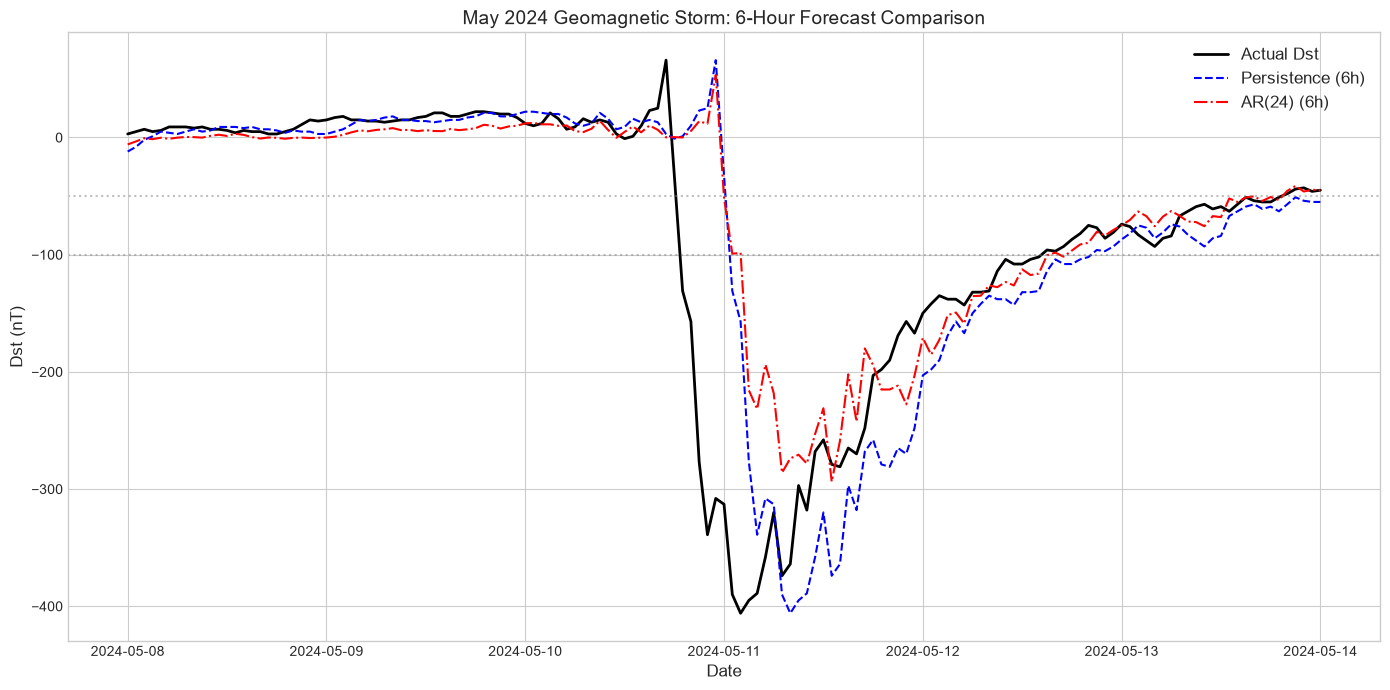

In [10]:
start_plot = '2024-05-08'
end_plot = '2024-05-14'

mask_plot = (test.index >= start_plot) & (test.index <= end_plot)
actual_plot = test.loc[mask_plot, target]
pers_plot = persistence_forecasts[6].loc[mask_plot]
ar_plot = ar_forecasts[6].loc[mask_plot]

plt.figure(figsize=(14, 7))
plt.plot(actual_plot.index, actual_plot, label='Actual Dst', color='black', linewidth=2)
plt.plot(pers_plot.index, pers_plot, label='Persistence (6h)', color='blue', linestyle='--')
plt.plot(ar_plot.index, ar_plot, label='AR(24) (6h)', color='red', linestyle='-.')

plt.axhline(-50, color='gray', linestyle=':', alpha=0.5)
plt.axhline(-100, color='gray', linestyle=':', alpha=0.5)

plt.title('May 2024 Geomagnetic Storm: 6-Hour Forecast Comparison', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Dst (nT)', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


# 11. Baseline Comparison
MAE vs forecast horizon and RMSE vs forecast horizon.

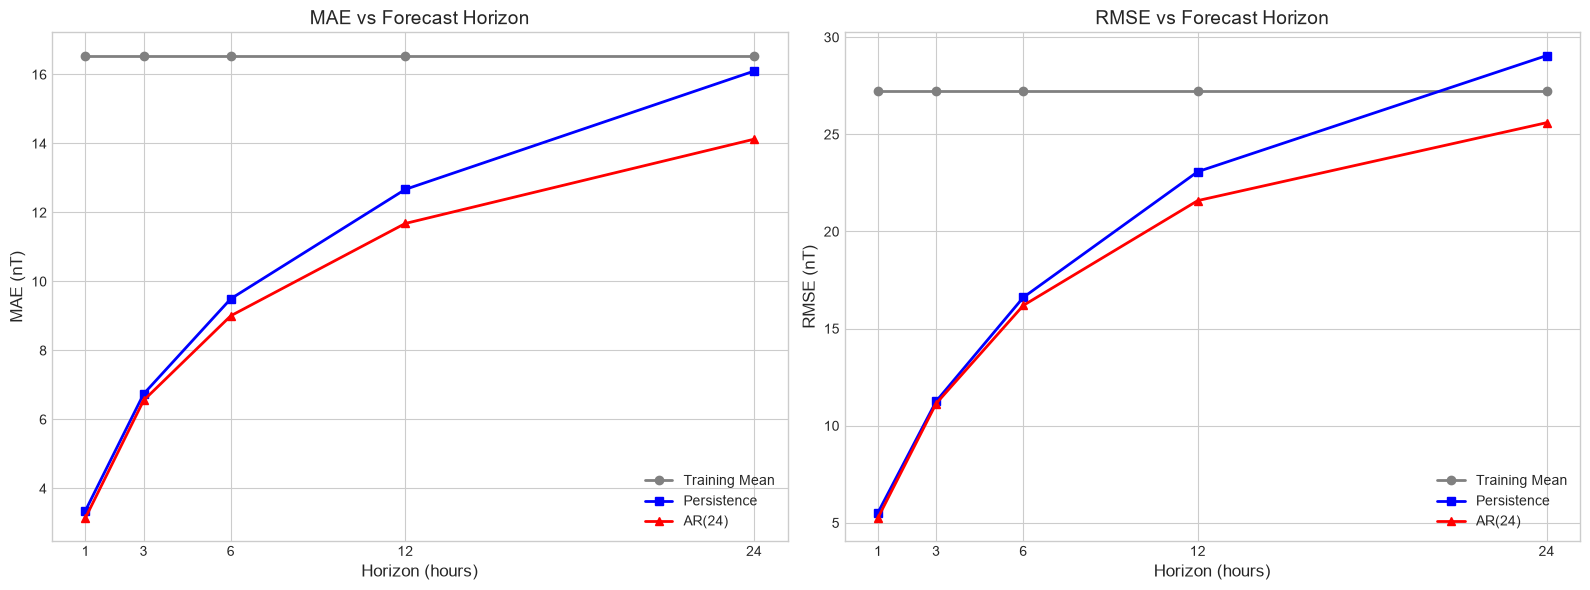

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

models = ['Training Mean', 'Persistence', 'AR(24)']
colors = {'Training Mean': 'gray', 'Persistence': 'blue', 'AR(24)': 'red'}
markers = {'Training Mean': 'o', 'Persistence': 's', 'AR(24)': '^'}

for model in models:
    model_data = results_df[results_df['Model'] == model]
    ax1.plot(model_data['Horizon_hours'], model_data['MAE'], 
             label=model, color=colors[model], marker=markers[model], linewidth=2)
    ax2.plot(model_data['Horizon_hours'], model_data['RMSE'], 
             label=model, color=colors[model], marker=markers[model], linewidth=2)

ax1.set_title('MAE vs Forecast Horizon', fontsize=14)
ax1.set_xlabel('Horizon (hours)', fontsize=12)
ax1.set_ylabel('MAE (nT)', fontsize=12)
ax1.set_xticks(horizons)
ax1.legend()

ax2.set_title('RMSE vs Forecast Horizon', fontsize=14)
ax2.set_xlabel('Horizon (hours)', fontsize=12)
ax2.set_ylabel('RMSE (nT)', fontsize=12)
ax2.set_xticks(horizons)
ax2.legend()

plt.tight_layout()
plt.show()


# 12. Final Findings
## Baseline Findings
1. **Global Performance**: Persistence is extremely hard to beat at the 1-hour horizon but degrades rapidly. AR(24) performs reasonably but still struggles with large sudden transitions.
2. **Horizon Degradation**: Forecasting error increases monotonically with the forecast horizon for all dynamic models. 
3. **May 2024 Storm**: During the extreme event, the 6-hour persistence forecast simply shifts the actual signal forward by 6 hours, missing the rapid decline completely in real-time. AR(24) also lags the sudden changes.
4. **AR vs Persistence**: AR(24) provides structurally different forecasts but often smooths the forecast and lags similarly to persistence during sharp transitions.
5. **Storm-Specific Errors**: Errors during storm conditions (Dst < -50 nT or -100 nT) are substantially larger than global average errors.
6. **Next Steps**: These baseline results establish the reference performance against which Chronos-2 and TimesFM-3 will later be evaluated.
